## Optimization & Markov Chain Monte Carlo Sampling: Application<sup>[1](https://andycasey.github.io/teaching/phs5000/4/),[2](https://andycasey.github.io/teaching/phs5000/5/),[3](https://arxiv.org/abs/1710.06068),[4](https://arxiv.org/abs/2304.05102)</sup>

In [1]:
# Preamble
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

import emcee as mc
import matplotlib as mpl
import numpy as np
import pandas as pd
import scipy as sci

import matplotlib.pyplot as plt
import scipy.optimize as op

from matplotlib.colors import ListedColormap
from matplotlib.patches import Ellipse

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["olivedrab", "steelblue", "firebrick", "goldenrod"]) 
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

N = 2**8

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(107/256, 1, N)
vals[:, 1] = np.linspace(142/256, 1, N)
vals[:, 2] = np.linspace(35/256, 1, N)

OliveDrab = ListedColormap(vals)
OliveDrab_r = OliveDrab.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(70/256, 1, N)
vals[:, 1] = np.linspace(130/256, 1, N)
vals[:, 2] = np.linspace(180/256, 1, N)

SteelBlue = ListedColormap(vals)
SteelBlue_r = SteelBlue.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(178/256, 1, N)
vals[:, 1] = np.linspace(34/256, 1, N)
vals[:, 2] = np.linspace(34/256, 1, N)

FireBrick = ListedColormap(vals)
FireBrick_r = FireBrick.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(218/256, 1, N)
vals[:, 1] = np.linspace(165/256, 1, N)
vals[:, 2] = np.linspace(32/256, 1, N)

GoldenRod = ListedColormap(vals)
GoldenRod_r = GoldenRod.reversed()

### Physical Setup

Thermal emission from the interstellar medium (ISM) is a useful tool to study the structure and evolution of these regions, especially in the context of star formation. The modified blackbody (MBB) spectrum of such dust clouds can be parametrized by an observed intensity

$$I_\nu = B_\nu(T) \left( 1 - e^{-\tau_\nu} \right)$$

for which we can make some simplifying assumptions. First, suppose a small optical depth $\tau_\nu \ll 1$ so that we can expand $e^{-\tau_\nu} \cong 1 - \tau_\nu$ and write

$$I_\nu \cong B_\nu(T) \tau_\nu$$

for the emission. Second, we formulate $\tau_\nu$ as the product of the mass surface density $\Sigma$ with the mass absorption coefficient $\kappa_\nu$ and assume $\Sigma$ to be a constant and $\kappa_\nu$ to follow a power law with $\beta$ as its spectral index. We get

$$I_\nu \cong B_\nu(T) \Sigma \kappa_0 \left( \nu / \nu_0 \right)^\beta$$

and can collect constant coefficients to find

$$I_\nu \cong \frac{2h\Sigma\kappa_0}{c^2\nu_0^\beta} \frac{\nu^{\beta + 3}}{e^{h\nu / kT} - 1} \propto \frac{\nu^{\beta + 3}}{e^{h\nu / kT} - 1} \equiv I_\nu / I_0 \equiv \tilde{I}_\nu \equiv \symup{MBB}(\nu,T,\beta)$$

for the overall  proportionality. In this, we have the frequency $\nu$ as the free variable on which our radiance measurements will depend. As for the parameters we want to optimize, there is the color temperature $T$ that depends on all actual dust temperatures along the line of sight as  well as the $\beta$ index, which characterizes the frequency dependence of the dust absorption cross section in our model. When emission originates from a source with a distribution of temperatures and spectral indices, one can apply a weighted sum of MBB functions. In our case, we will stick to the toy model of a source in the ISM that is well described by a single component. Added effects from the measurement process due to convolution when the beam width matches or exceeds pixel sizes are neglected to keep things as simple as possible.

In [2]:
# Function
def I(f, T, b):
    h = sci.constants.Planck * 1e7      # cgs units
    k = sci.constants.Boltzmann * 1e7   # cgs units
    T *= 30.0   # adjust parameter magnitude
    return f**(b + 3.0) / (np.exp(h * f / (k * T)) - 1.0)

For our dataset, we draw from a Gaussian centered on the MBB line with uncertainties only in the intensity dimension and perfectly known frequencies. The true parameter values we pick will be

$$\begin{aligned}
T = 15 \text{ K} && \beta = 1.9
\end{aligned}$$

with $3\%$ relative observational noise.

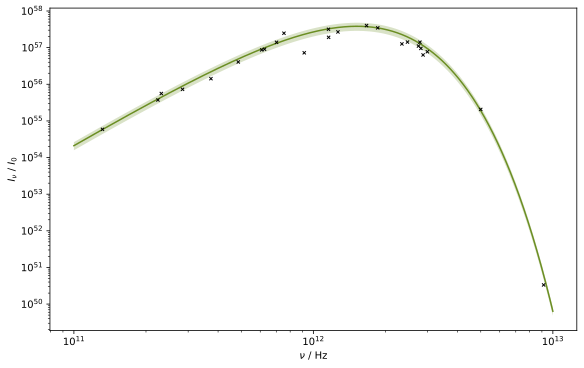

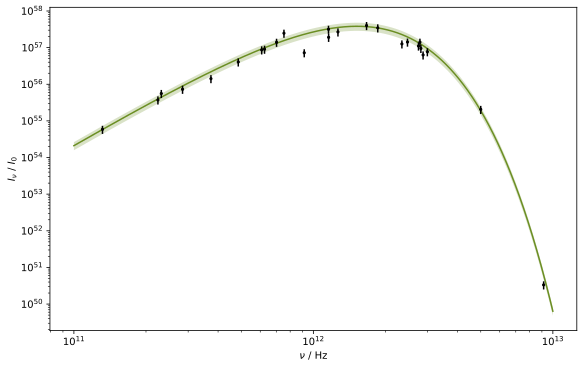

In [3]:
## Parameters
tT, tb = 15 / 30.0, 1.9

# Truth
x = np.linspace(1e11, 1e13, 1000)
y = I(x, tT, tb)

# Data
N = 25
u = 0.25 #   relative uncertaintiy

np.random.seed(123)   # set seed for pseudo random number generation

df = np.power(10, np.random.uniform(11, 13, N))

dI = I(df, tT, tb)
dI += np.random.normal(0.0, u * dI)

dIerr = u * np.abs(dI)

plt.fill_between(x, (1 + u) * y, (1 - u) * y, alpha=0.25)
plt.plot(x, y)
plt.plot(df, dI, 'kx', ms=3.21)

plt.xlabel(r'$\nu$ / Hz')
plt.ylabel(r'$I_\nu$ / $I_0$')

plt.xscale('log')
plt.yscale('log')

plt.show()
plt.close()

# Measurement
plt.fill_between(x, (1 + u) * y, (1 - u) * y, alpha=0.25)
plt.plot(x, y)
plt.errorbar(df, dI, yerr=dIerr, fmt='k.', ms=4.32)

plt.xlabel(r'$\nu$ / Hz')
plt.ylabel(r'$I_\nu$ / $I_0$')

plt.xscale('log')
plt.yscale('log')

plt.show()
plt.close()

### Likelihood

Since we are assuming independent measurements, we can define

$$P(\tilde{I}_\nu|\nu,\sigma,T,\beta) = \prod_{i=1}^N p\bigl(\tilde{I}_\nu^i\big|\nu_i,\sigma_i,T,\beta\bigr) = \prod_{i=1}^N \frac{1}{\sqrt{2\pi\sigma_i^2}}\exp\left(-\frac{\bigl(\tilde{I}_\nu^i - \symup{MBB}(\nu_i,T,\beta)\bigr)^2}{2\sigma_i^2}\right)$$

as the linear likelihood or equivalently

$$\log P(\tilde{I}_\nu|\nu,\sigma,T,\beta) = -\frac{N\log 2\pi}{2} - \sum_{i=1}^N \log \sigma_i - \sum_{i=1}^N \frac{\bigl(\tilde{I}_\nu^i - \symup{MBB}(\nu_i,T,\beta)\bigr)^2}{2\sigma_i^2}$$

for the positive logarithmic likelihood. In this, the only varying part containing our parameters is

$$\chi^2 = \sum_{i=1}^N \frac{\bigl(\tilde{I}_\nu^i - \symup{MBB}(\nu_i,T,\beta)\bigr)^2}{\sigma_i^2}$$

which we will use for our optimization.

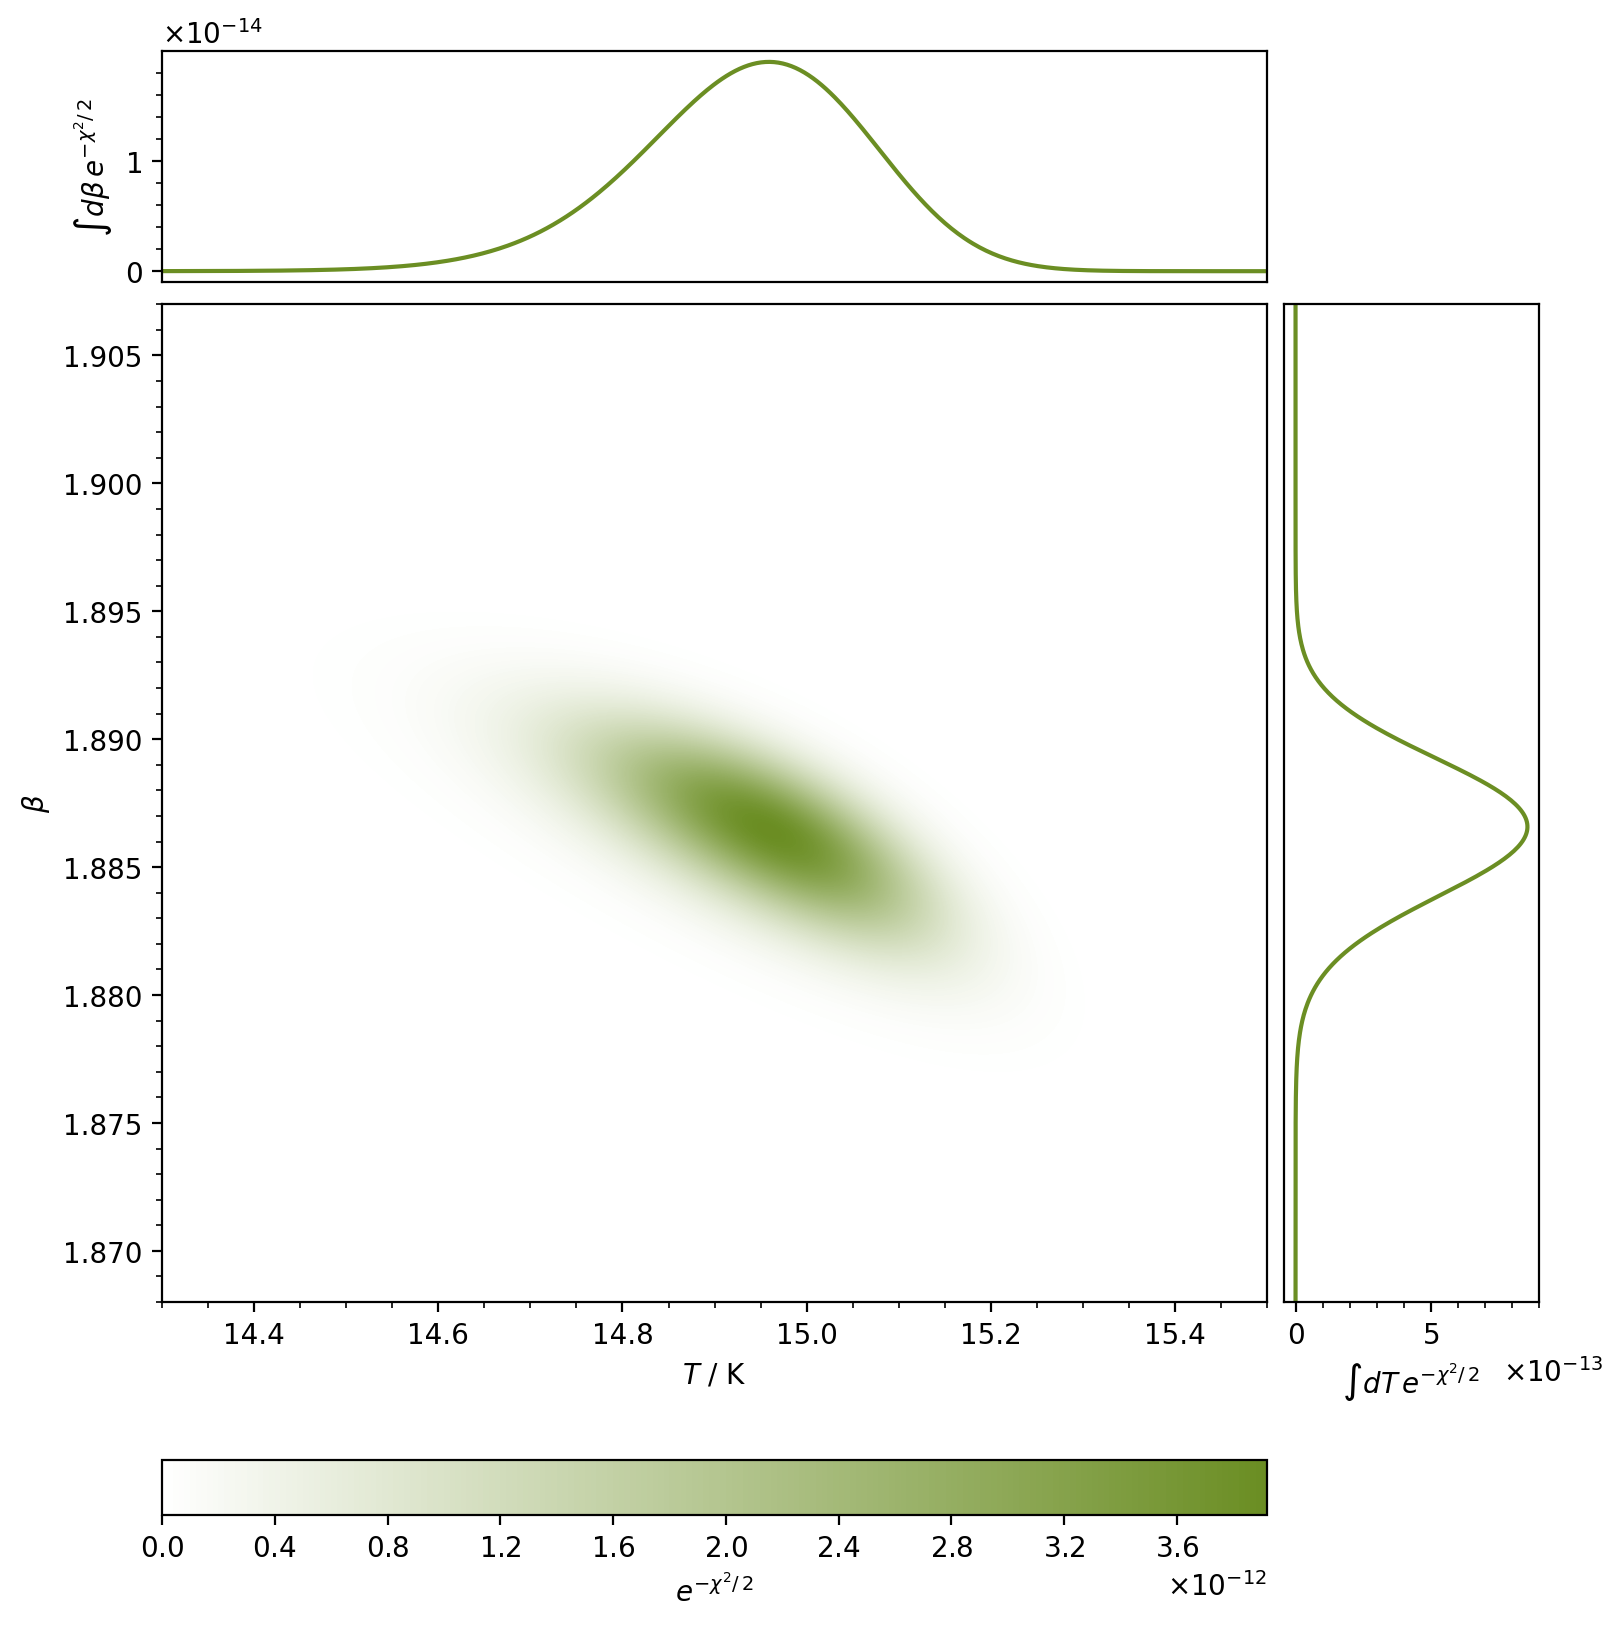

In [4]:
%config InlineBackend.figure_formats = ['retina']

def chiSq(mI, mf, ms, pT, pb):
    return np.sum((mI - I(mf, pT, pb))**2 / ms**2)

s = 512

X = np.linspace(14.3, 15.5, s) / 30.0
Y = np.linspace(1.868, 1.907, s)

X, Y = np.meshgrid(X, Y)

Z = np.zeros(X.shape)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = chiSq(dI, df, dIerr, X[i, j], Y[i, j])

fig, ax = plt.subplots(2, 2, figsize=(8, 8), height_ratios=[1.5, 6.5], width_ratios=[6.5, 1.5])

cnt = ax[1,0].contourf(30.0 * X, Y, np.exp(-Z/2), 256, cmap=OliveDrab_r)
cnt.set_edgecolor('face')

cb = plt.colorbar(cnt, location='bottom')
cb.set_label(r'$e^{-\chi^2/\,2}$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

xlim = ax[1, 0].set_xlim()
ylim = ax[1, 0].set_ylim()

ax[1,0].set_xlabel(r'$T$ / K')
ax[1,0].set_ylabel(r'$\beta$')

ax[0, 1].axis('off')

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

ax[0,0].plot(30.0 * X[0,:], np.sum(np.exp(-Z / 2) * (Y[1, 0] - Y[0, 0]), axis=0))
ax[0,0].set_xlim(xlim)
ax[0,0].set_ylabel(r'$\int d\beta \, e^{-\chi^2/\,2}$')
ax[0,0].get_xaxis().set_ticks([])
ax[0,0].yaxis.set_major_formatter(formatter)

ax[1,1].plot(np.sum(np.exp(-Z / 2) * 30.0 * (X[0, 1] - X[0, 0]), axis=1), Y[:,0])
ax[1,1].set_ylim(ylim)
ax[1,1].set_xlabel(r'$\int dT \, e^{-\chi^2/\,2}$')
ax[1,1].get_yaxis().set_ticks([])
ax[1,1].xaxis.set_major_formatter(formatter)

exp = ax[1,1].xaxis.get_offset_text()
cur = exp.get_position()
exp.set_position((cur[0] + 0.25, cur[1]))

plt.show()
plt.close()

%config InlineBackend.figure_formats = ['svg']

In the above plot, the colormap is linearly proportional to the likelihood in parameter space. We see that our parameters are anticorrelated, meaning that if we reduce one, the other is bound to increase. Our problem is also convex, making it much easier to optimize and sample from.

### Priors

At this point, we could introduce prior knowledge on how our parameters behave. Typical values are $\beta \in 1.5-2.0$ and $T \in 10-25 \text{ K}$ as well as $T > 0$ for a fundamental constraint. According to Bayes,

$$P(T,\beta|\tilde{I}_\nu,\nu,\sigma,\mathcal{M}) = \frac{P(\tilde{I}_\nu|\nu,\sigma,T,\beta,\mathcal{M})\,P(T,\beta|\nu,\sigma,\mathcal{M})}{P(\tilde{I}_\nu|\nu,\sigma,\mathcal{M})}$$

is the posterior probability which incorporates our likelihood and prior in the numerator and the fully marginalized likelihood in the denominator. Included in the $\mathcal{M}$ conditioning is the entirety of what we previously believe about the model. Looking at the shape of our likelihood landscape, it would require very strong priors to make a significant difference, so the inclusion is omitted for the sake of brevity.

### Optimization

$$\begin{aligned}
\partial_T \symup{MBB} = \frac{h\nu^{\beta + 4}e^{h\nu / kT}}{kT^2\bigl(e^{h\nu / kT} - 1\bigr)^2} &&
\partial_\beta \symup{MBB} = \frac{\log(\nu)\nu^{\beta + 3}}{e^{h\nu / kT} - 1}
\end{aligned}$$

$$\begin{aligned}
\nabla \symup{MBB} = \begin{pmatrix}\partial_T \\ \partial_\beta\end{pmatrix} \symup{MBB} &&
\nabla \chi^2 = \sum_{i=1}^N \frac{-2\bigl(\tilde{I}_\nu^i - \symup{MBB}\bigr)\nabla \symup{MBB}}{\sigma_i^2}
\end{aligned}$$

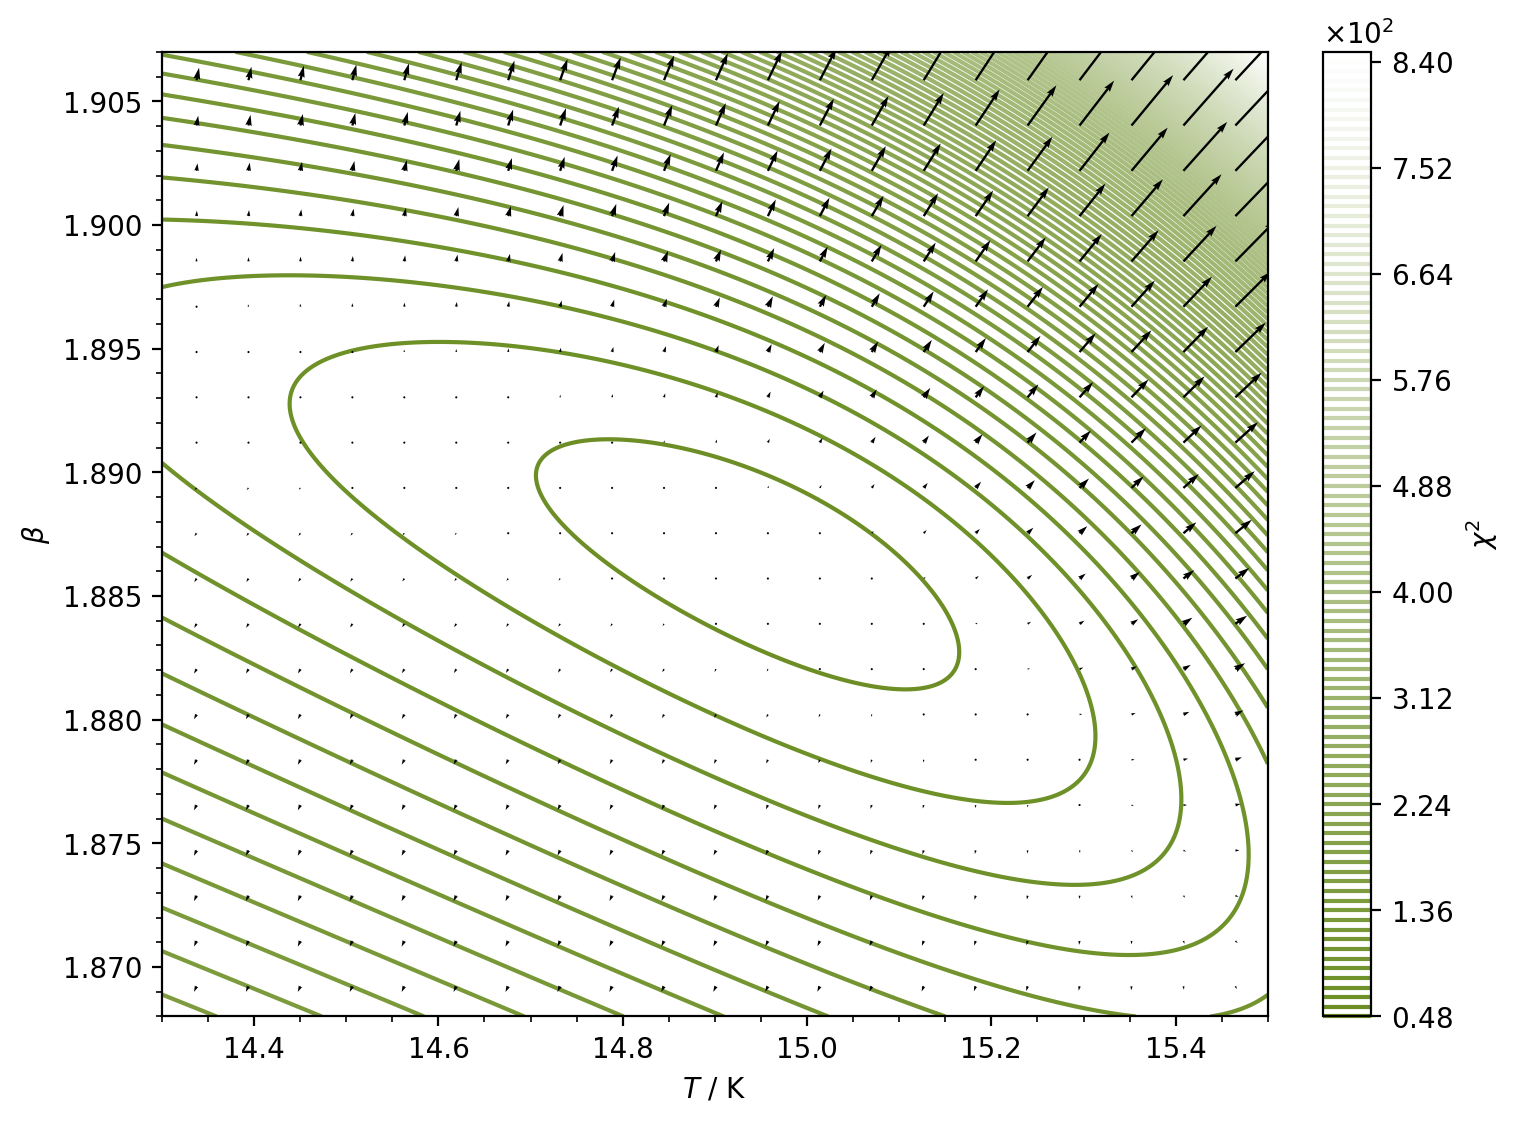

In [26]:
%config InlineBackend.figure_formats = ['retina']

# Derivative
def gradIX(f, T, b):
    h = sci.constants.Planck * 1e7      # cgs units
    k = sci.constants.Boltzmann * 1e7   # cgs units
    T *= 30.0   # adjust parameter magnitude
    return 30.0 * h * f**(b + 4.0) * np.exp(h * f / (k * T)) / (k * T**2.0 * (np.exp(h * f / (k * T)) - 1.0)**2.0)

def gradIY(f, T, b):
    h = sci.constants.Planck * 1e7      # cgs units
    k = sci.constants.Boltzmann * 1e7   # cgs units
    T *= 30.0   # adjust parameter magnitude
    return np.log(f) * f**(b + 3.0) / (np.exp(h * f / (k * T)) - 1.0)
    
# Gradient
def gradChiSqX(mI, mf, ms, pT, pb):
    return np.sum(-2 * (mI - I(mf, pT, pb)) * gradIX(mf, pT, pb) / ms**2)

def gradChiSqY(mI, mf, ms, pT, pb):
    return np.sum(-2 * (mI - I(mf, pT, pb)) * gradIY(mf, pT, pb) / ms**2)

w = 24
v = int((s % w + w) / 2)

gradX = np.zeros(X[v::w, v::w].shape)
gradY = np.zeros(X[v::w, v::w].shape)

for i in range(X[v::w, v::w].shape[0]):
    for j in range(X[v::w, v::w].shape[1]):
        gradX[i, j] = gradChiSqX(dI, df, dIerr, X[v::w, v::w][i, j], Y[v::w, v::w][i, j])
        gradY[i, j] = gradChiSqY(dI, df, dIerr, X[v::w, v::w][i, j], Y[v::w, v::w][i, j])

plt.fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5))

cnt = ax.contour(30.0 * X, Y, Z, 128, cmap=OliveDrab, zorder=-1)

cb = plt.colorbar(cnt, location='right')
cb.set_label(r'$\chi^2$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

quiv = ax.quiver(30.0 * X[v::w, v::w], Y[v::w, v::w], gradX, gradY, pivot='tail', scale=9e5, width=2.1e-3)

ax.set_xlabel(r'$T$ / K')
ax.set_ylabel(r'$\beta$')

plt.show()
plt.close()

%config InlineBackend.figure_formats = ['svg']

### Gradient Descent

$$\texttt{while any component } \left|\frac{\theta_{k+1}^l - \theta_k^l}{\theta_k^l}\right| \geq \epsilon \texttt{ iterate on vector } \theta_{k+1} = \theta_k - \alpha_k \nabla \chi^2 \big|_{\theta_k} \texttt{ with accepted relative error } \epsilon\in (0,1)$$

### Backtracking Line Search

$$\texttt{until } \chi^2 \big|_{\theta_k} - \chi^2 \big|_{\theta_k - \alpha_j \nabla\chi^2 \big|_{\theta_k}} \geq \kappa\alpha_j \Bigl(\nabla\chi^2\big|_{\theta_k}\Bigr)^2 \texttt{ do } \alpha_j = \tau\alpha_{j-1} \texttt{ where } \alpha_j \in \mathbb{R}^+ \texttt{ and } \tau,\kappa\in (0,1)$$


initialization:   T = 15.40 K   ß = 1.905
  optimization:   T = 14.96 K   ß = 1.886
    iterations:   k = 37

initialization:   T = 14.40 K   ß = 1.870
  optimization:   T = 14.96 K   ß = 1.886
    iterations:   k = 40

initialization:   T = 15.45 K   ß = 1.880
  optimization:   T = 14.96 K   ß = 1.886
    iterations:   k = 39


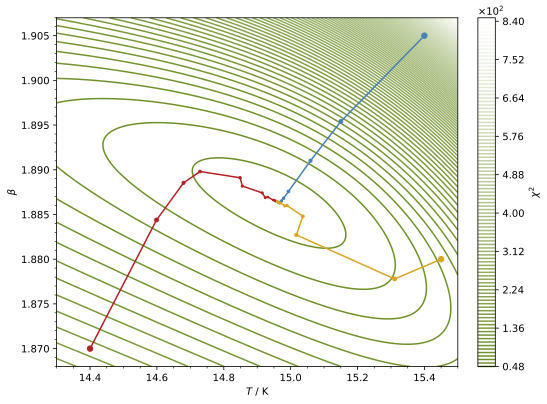

In [43]:
def gradDescLinSear(sT, sb):
    theta = np.array([[sT / 30.0, sb]])
    eps = 1e-16
    k = 0
    while True:
        gX = gradChiSqX(dI, df, dIerr, *theta[k, :])
        gY = gradChiSqY(dI, df, dIerr, *theta[k, :])
        alp = 1e-4
        kap = 0.5
        tau = 0.5
        j = 0
        while chiSq(dI, df, dIerr, *theta[k, :]) \
        - chiSq(dI, df, dIerr, *(theta[k, :] - alp * np.array([gX, gY]))) \
        < kap * alp * (gX**2 + gY**2):
            alp *= tau
            j += 1
        theta = np.append(theta, [theta[k, :] - alp * np.array([gX, gY])], axis=0)
        k += 1
        if np.abs(theta[k, 0] - theta[k - 1, 0]) / theta[k - 1, 0] \
        < eps and np.abs(theta[k, 1] - theta[k - 1, 1]) / theta[k - 1, 1] < eps:
           break
    print()
    print(f'initialization:   T = {sT:.2f} K   ß = {sb:.3f}')
    print(f'  optimization:   T = {30.0 * theta[-1, 0]:.2f} K   ß = {theta[-1, 1]:.3f}')
    print(f'    iterations:   k = {k}')
    return [theta, k]

th1, k1 = gradDescLinSear(15.40, 1.905)
th2, k2 = gradDescLinSear(14.40, 1.870)
th3, k3 = gradDescLinSear(15.45, 1.880)

plt.fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5))

cnt = ax.contour(30.0 * X, Y, Z, 128, cmap=OliveDrab, zorder=-1)

cb = plt.colorbar(cnt, location='right')
cb.set_label(r'$\chi^2$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

ax.scatter([], [])
ax.plot([], [])

ax.scatter(30.0 * th1[:, 0], th1[:, 1], s=(30 / (np.arange(k1 + 1) + 1)), zorder=10)
ax.plot(30.0 * th1[:, 0], th1[:, 1], zorder=10)

ax.scatter(30.0 * th2[:, 0], th2[:, 1], s=(30 / (np.arange(k2 + 1) + 1)), zorder=20)
ax.plot(30.0 * th2[:, 0], th2[:, 1], zorder=20)

ax.scatter(30.0 * th3[:, 0], th3[:, 1], s=(30 / (np.arange(k3 + 1) + 1)), zorder=30)
ax.plot(30.0 * th3[:, 0], th3[:, 1], zorder=30)

ax.set_xlabel(r'$T$ / K')
ax.set_ylabel(r'$\beta$')

plt.show()
plt.close()